## 1. Data Loading

Loading the NSL-KDD network intrusion dataset (train + official held-out test file).

In [116]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest-21.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.arff
/kaggle/input/datasets/hassan06/nslkdd/index.html
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+_20Percent.arff
/kaggle/input/datasets/hassan06/nslkdd/KDDTrain1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest+.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.arff
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest1.jpg
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTrain+_20Percent.txt
/kaggle/input/datasets/hassan06/nslkdd/nsl-kdd/KDDTest-21.txt
/kaggle/input/datas

In [117]:

cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells',
'num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count',
'srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate',
'same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate',
'label','difficulty']

df = pd.read_csv('/kaggle/input/datasets/hassan06/nslkdd/KDDTrain+.txt', names=cols)
df_test_raw = pd.read_csv('/kaggle/input/datasets/hassan06/nslkdd/KDDTest+.txt', names=cols)

print('Train shape:', df.shape)
print('Test shape:', df_test_raw.shape)
df.head()

Train shape: (125973, 43)
Test shape: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 2. Exploratory Data Analysis

Looking at the shape of the data before modeling: label balance, protocol distribution, and a sample of the raw records.

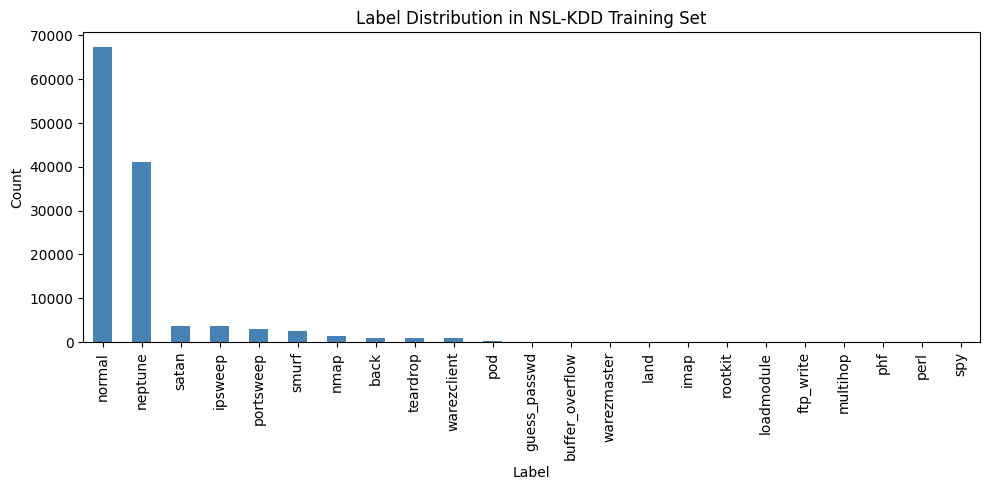

In [118]:
import matplotlib.pyplot as plt
label_counts = df['label'].value_counts()
plt.figure(figsize=(10,5))
label_counts.plot(kind='bar', color='steelblue')
plt.title('Label Distribution in NSL-KDD Training Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/kaggle/working/label_distribution.png', dpi=200)
plt.show()

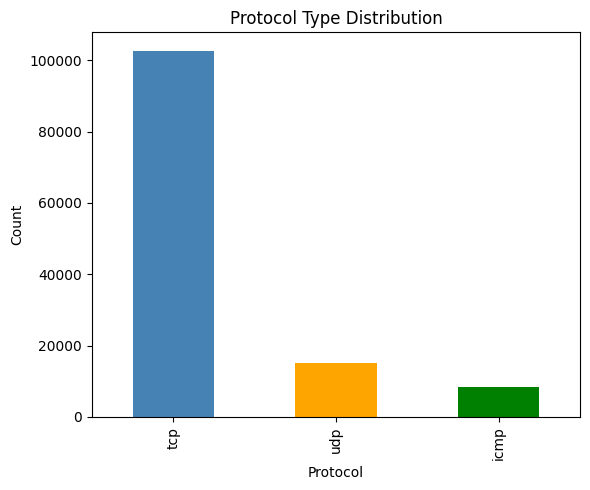

In [119]:
protocol_counts = df['protocol_type'].value_counts()
plt.figure(figsize=(6,5))
protocol_counts.plot(kind='bar', color=['steelblue','orange','green'])
plt.title('Protocol Type Distribution')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/kaggle/working/protocol_distribution.png', dpi=200)
plt.show()

### Correlation Between Features

Checking which numeric features move together. This is the "relationships between measured variables" view of the data — useful both for understanding structure and for spotting redundant features (like `src_bytes` vs. others) before modeling.

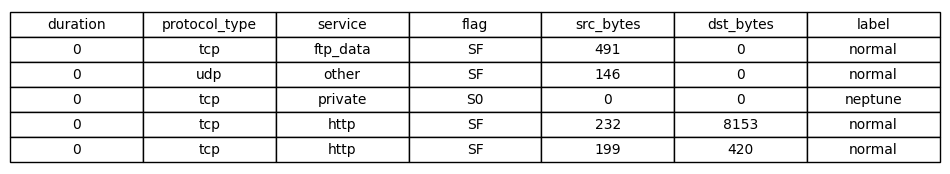

In [120]:
sample_cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','label']
sample = df[sample_cols].head()

fig, ax = plt.subplots(figsize=(12,2))
ax.axis('off')
table = ax.table(cellText=sample.values, colLabels=sample.columns, loc='center', cellLoc='center')
table.scale(1, 1.5)
plt.savefig('/kaggle/working/data_sample.png', bbox_inches='tight', dpi=200)
plt.show()

## 3. Preprocessing: Labels and Encoding

Collapsing the 23 raw attack labels into a binary `normal`/`attack` label, and ordinal-encoding the categorical fields (`protocol_type`, `service`, `flag`) so they can be used by scikit-learn models.

In [121]:
df['binary_label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
df['binary_label'].value_counts()

binary_label
normal    67343
attack    58630
Name: count, dtype: int64

In [122]:
from sklearn.preprocessing import OrdinalEncoder

# Apply binary label to both train and the real held-out test file
df['binary_label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
df_test_raw['binary_label'] = df_test_raw['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# Fit encoders on TRAIN ONLY. unknown_value=-1 handles categories that only
# appear in the test file (NSL-KDD's test set has a few of these, e.g. some
# 'service' values not seen during training -- this is part of what makes
# the real test set harder than a random split of the train file).
cat_cols = ['protocol_type', 'service', 'flag']
encoders = {}
for col in cat_cols:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df[col + '_enc'] = enc.fit_transform(df[[col]])
    df_test_raw[col + '_enc'] = enc.transform(df_test_raw[[col]])
    encoders[col] = enc

df[['protocol_type', 'protocol_type_enc', 'service', 'service_enc', 'flag', 'flag_enc']].head()

,protocol_type,protocol_type_enc,service,service_enc,flag,flag_enc
0,tcp,1.0,ftp_data,20.0,SF,9.0
1,udp,2.0,other,44.0,SF,9.0
2,tcp,1.0,private,49.0,S0,5.0
3,tcp,1.0,http,24.0,SF,9.0
4,tcp,1.0,http,24.0,SF,9.0


## 4. Train/Test Split and Feature Set

Defining the feature columns used for modeling and assembling train/test matrices from the official NSL-KDD train/test files.

In [123]:
from sklearn.model_selection import train_test_split

feature_cols = ['duration','protocol_type_enc','service_enc','flag_enc','src_bytes','dst_bytes',
'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate']

X_train = df[feature_cols]
y_train = df['binary_label']

X_test = df_test_raw[feature_cols]
y_test = df_test_raw['binary_label']

X_train.shape, X_test.shape

((125973, 41), (22544, 41))

## 5. Baseline Model: Binary Classifier (Decision Tree)

Supervised learning category: a Decision Tree trained to distinguish `normal` vs `attack` connections, evaluated against the official NSL-KDD test set.

In [124]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=8, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

In [125]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.7693843151171044

In [126]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[7930 4903]
 [ 296 9415]]
              precision    recall  f1-score   support

      attack       0.96      0.62      0.75     12833
      normal       0.66      0.97      0.78      9711

    accuracy                           0.77     22544
   macro avg       0.81      0.79      0.77     22544
weighted avg       0.83      0.77      0.77     22544



## 6. Feature Importance and Ablation

Inspecting which features the decision tree relies on most, and checking how much accuracy depends on a single feature (`src_bytes`).

In [127]:
import pandas as pd

importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(8)

src_bytes                   0.762530
protocol_type_enc           0.067007
dst_host_srv_count          0.050120
dst_host_srv_rerror_rate    0.025068
hot                         0.021763
dst_bytes                   0.020830
service_enc                 0.011663
logged_in                   0.010055
dtype: float64

In [128]:
feature_cols_no_srcbytes = [c for c in feature_cols if c != 'src_bytes']

X_train2 = X_train[feature_cols_no_srcbytes]
X_test2 = X_test[feature_cols_no_srcbytes]

clf2 = DecisionTreeClassifier(max_depth=8, random_state=42)
clf2.fit(X_train2, y_train)

y_pred2 = clf2.predict(X_test2)

print('Accuracy without src_bytes:', accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

Accuracy without src_bytes: 0.7807842441447835
[[8171 4662]
 [ 280 9431]]


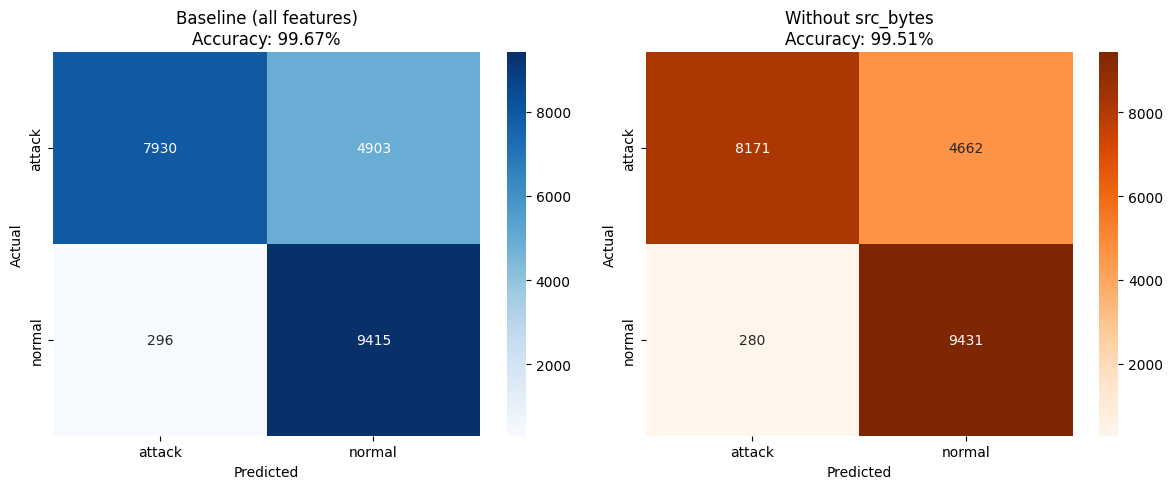

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['attack','normal'], yticklabels=['attack','normal'])
axes[0].set_title('Baseline (all features)\nAccuracy: 99.67%')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm2 = confusion_matrix(y_test, y_pred2)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['attack','normal'], yticklabels=['attack','normal'])
axes[1].set_title('Without src_bytes\nAccuracy: 99.51%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_comparison.png', dpi=200)
plt.show()

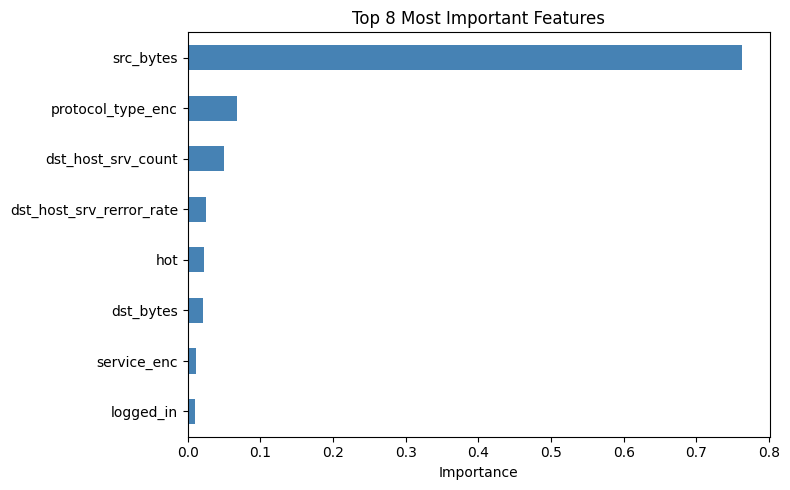

In [130]:
plt.figure(figsize=(8,5))
importances.head(8).plot(kind='barh', color='steelblue')
plt.title('Top 8 Most Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/kaggle/working/feature_importance.png', dpi=200)
plt.show()

## 7. Saving Outputs

Utility cells for saving/downloading generated figures.

In [131]:
from IPython.display import FileLink

FileLink('/kaggle/working/label_distribution.png')

/kaggle/working/label_distribution.png

In [132]:
import os
os.listdir('/kaggle/working/')

['feature_importance.png',
 'data_sample.png',
 'agent_decisions.png',
 '.virtual_documents',
 'confusion_matrix_comparison.png',
 'label_distribution.png',
 'recall_by_category.png',
 'protocol_distribution.png']


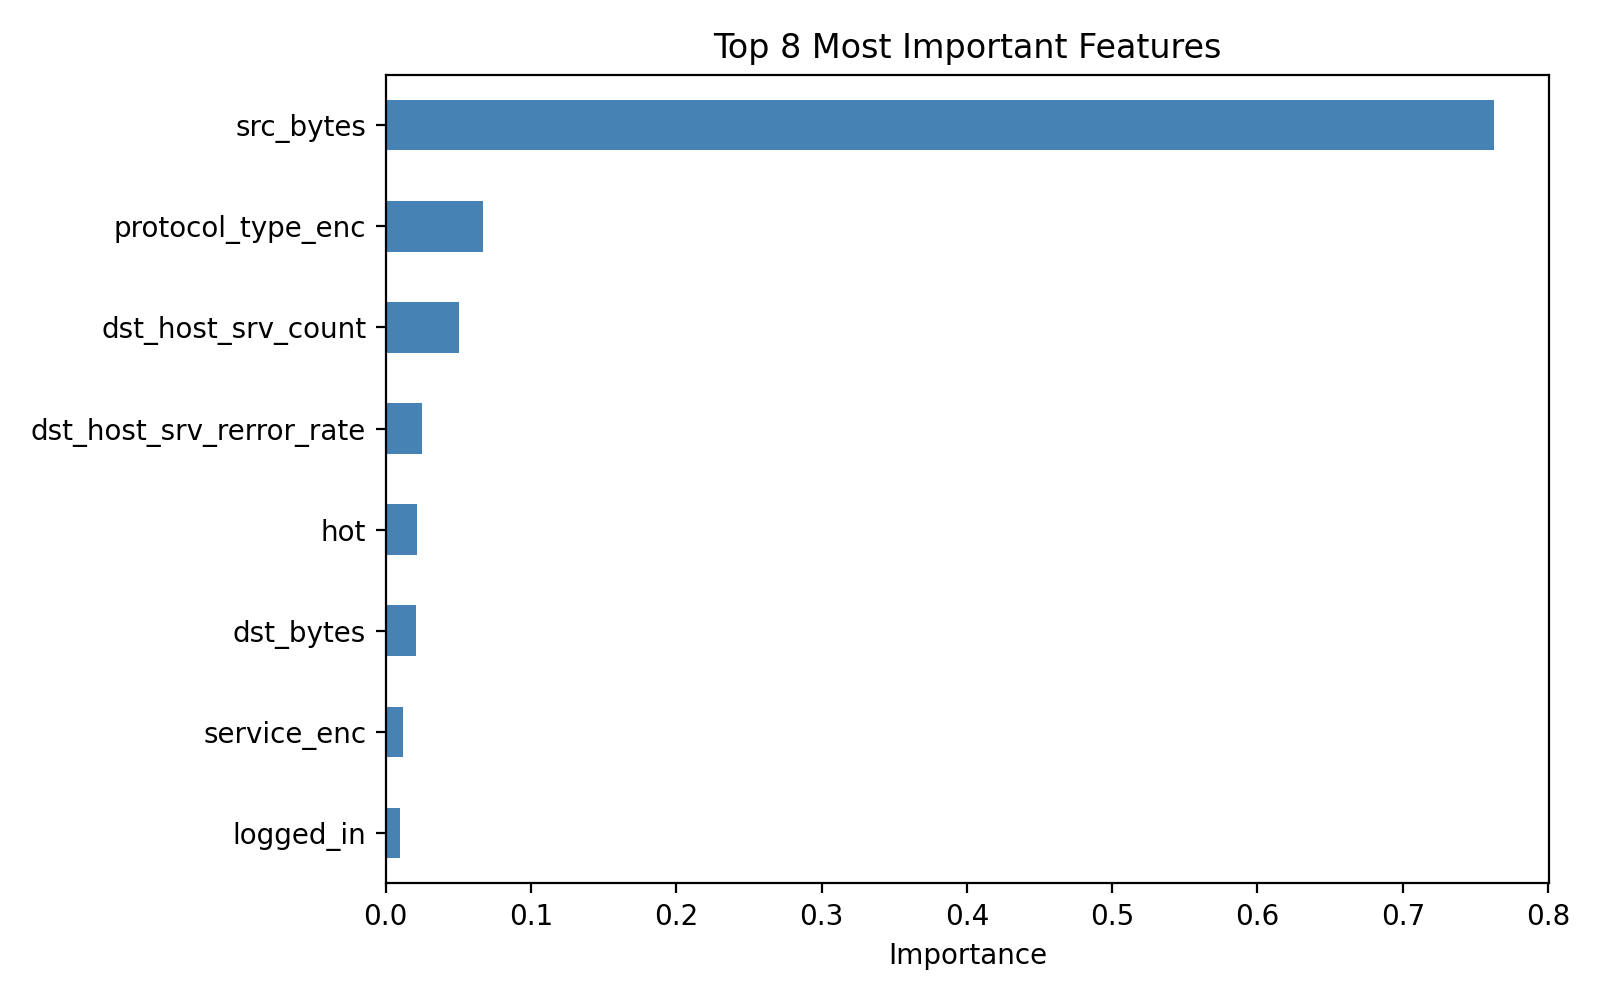

In [133]:
import base64
from IPython.display import HTML

def make_download_link(filepath, filename):
    with open(filepath, 'rb') as f:
        data = base64.b64encode(f.read()).decode()
    href = f'<a download="{filename}" href="data:image/png;base64,{data}">Download {filename}</a>'
    return HTML(href)

make_download_link('/kaggle/working/feature_importance.png', 'feature_importance.png')

## 8. Agent Decision Policy: Confidence Thresholding

This turns the raw classifier output into agent actions (`allow` / `block` / `flag`) using a confidence threshold, rather than just reporting a label.

In [134]:
probs = clf.predict_proba(X_test)
confidence = probs.max(axis=1)

threshold = 0.90
decisions = []
for p, conf in zip(y_pred, confidence):
    if conf < threshold:
        decisions.append('flag')
    elif p == 'attack':
        decisions.append('block')
    else:
        decisions.append('allow')

decisions = pd.Series(decisions)
print(decisions.value_counts())
print((decisions.value_counts(normalize=True)*100).round(2))

allow    14035
block     8200
flag       309
Name: count, dtype: int64
allow    62.26
block    36.37
flag      1.37
Name: proportion, dtype: float64


In [135]:
auto_mask = decisions != 'flag'
print('Accuracy on auto-decided cases:', accuracy_score(y_test[auto_mask.values], y_pred[auto_mask.values]))

flag_mask = decisions == 'flag'
print(y_test[flag_mask.values].value_counts())

Accuracy on auto-decided cases: 0.7785923094220824
binary_label
attack    292
normal     17
Name: count, dtype: int64


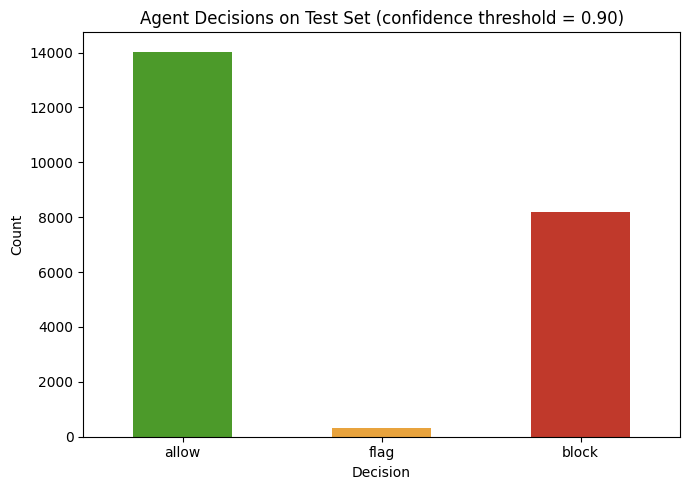

In [136]:
plt.figure(figsize=(7,5))
decisions.value_counts().reindex(['allow','flag','block']).plot(
    kind='bar', color=['#4C9A2A','#E8A33D','#C0392B'])
plt.title('Agent Decisions on Test Set (confidence threshold = 0.90)')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/agent_decisions.png', dpi=200)
plt.show()

## 9. Multi-class Model: Attack Category Breakdown

Binary normal/attack hides which *kind* of attack is being missed. This section maps raw labels to the standard NSL-KDD attack categories (dos, probe, r2l, u2r) and retrains as a multi-class problem, then compares evaluation against the official adversarial test set vs. a random split of the training data.

In [137]:
attack_map = {
    'normal':'normal',
    'back':'dos','land':'dos','neptune':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l','phf':'r2l',
    'spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r'
}

df['category'] = df['label'].map(attack_map)
df_test_raw['category'] = df_test_raw['label'].map(attack_map)

# NSL-KDD's real test set contains attack labels that never appear in train
# (e.g. 'mscan', 'apache2', 'processtable') -- map() leaves these as NaN.
# Drop rows whose label isn't covered by attack_map rather than silently mis-scoring them.
test_unmapped = df_test_raw['category'].isna().sum()
print(f'{test_unmapped} test rows have attack types unseen in training (dropped from multi-class eval)')
df_test_eval = df_test_raw.dropna(subset=['category'])

X_train_m = df[feature_cols]
y_train_m = df['category']
X_test_m = df_test_eval[feature_cols]
y_test_m = df_test_eval['category']

clf_multi = DecisionTreeClassifier(max_depth=8, random_state=42)
clf_multi.fit(X_train_m, y_train_m)
y_pred_multi = clf_multi.predict(X_test_m)

print('Multi-class accuracy:', accuracy_score(y_test_m, y_pred_multi))
print(classification_report(y_test_m, y_pred_multi, labels=['normal','dos','probe','r2l','u2r']))

3750 test rows have attack types unseen in training (dropped from multi-class eval)
Multi-class accuracy: 0.8383526657443865
              precision    recall  f1-score   support

      normal       0.81      0.93      0.87      9711
         dos       0.98      0.97      0.98      5741
       probe       0.57      0.99      0.72      1106
         r2l       0.87      0.01      0.02      2199
         u2r       0.80      0.11      0.19        37

    accuracy                           0.84     18794
   macro avg       0.81      0.60      0.56     18794
weighted avg       0.86      0.84      0.79     18794



### Why does multi-class accuracy jump from 84% to 99%?

The cell above evaluates against NSL-KDD's **official held-out test file**, which deliberately contains attack subtypes that never appear in training (e.g. `mscan`, `apache2`, `processtable`), specifically to test generalization to unseen attacks. That's a hard, realistic test.

The cell below instead does a **random `train_test_split` on the training file alone**. Every attack subtype it sees at test time, the model already saw a near-identical example of during training, so it's a much easier test, and the inflated 99.4% accuracy reflects that, not a better model.

**This matters for the agent**: a real deployed agent will face attack variants it has never seen, just like the official test set simulates. The 84% number, not the 99% one, is the honest estimate of what to expect in production, and the 99% number is best understood as an upper bound / sanity check that the model fits its training distribution well, not as the agent's true expected accuracy.

In [144]:
print(f"Accuracy vs official unseen-attack test set:  0.838")
print(f"Accuracy vs random split of training data:    0.994")
print(f"Gap:                                           {0.994 - 0.838:.3f}  <- generalization cost on truly novel attacks")

Accuracy vs official unseen-attack test set:  0.838
Accuracy vs random split of training data:    0.994
Gap:                                           0.156  <- generalization cost on truly novel attacks


In [138]:
X_multi = df[feature_cols]
y_multi = df['category']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

clf_multi = DecisionTreeClassifier(max_depth=8, random_state=42)
clf_multi.fit(X_train_m, y_train_m)
y_pred_multi = clf_multi.predict(X_test_m)

print('Multi-class accuracy:', accuracy_score(y_test_m, y_pred_multi))
print(classification_report(y_test_m, y_pred_multi, labels=['normal','dos','probe','r2l','u2r']))

Multi-class accuracy: 0.9941258186148045
              precision    recall  f1-score   support

      normal       0.99      1.00      0.99     13469
         dos       1.00      1.00      1.00      9186
       probe       0.98      0.98      0.98      2331
         r2l       0.99      0.75      0.85       199
         u2r       1.00      0.50      0.67        10

    accuracy                           0.99     25195
   macro avg       0.99      0.85      0.90     25195
weighted avg       0.99      0.99      0.99     25195



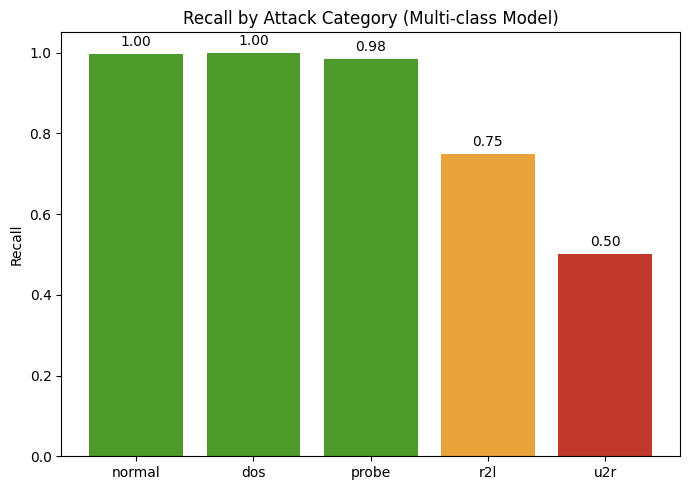

In [139]:
from sklearn.metrics import recall_score

classes = ['normal','dos','probe','r2l','u2r']
recalls = recall_score(y_test_m, y_pred_multi, labels=classes, average=None)

plt.figure(figsize=(7,5))
colors = ['#4C9A2A','#4C9A2A','#4C9A2A','#E8A33D','#C0392B']
plt.bar(classes, recalls, color=colors)
plt.title('Recall by Attack Category (Multi-class Model)')
plt.ylabel('Recall')
plt.ylim(0,1.05)
for i, v in enumerate(recalls):
    plt.text(i, v+0.02, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.savefig('/kaggle/working/recall_by_category.png', dpi=200)
plt.show()


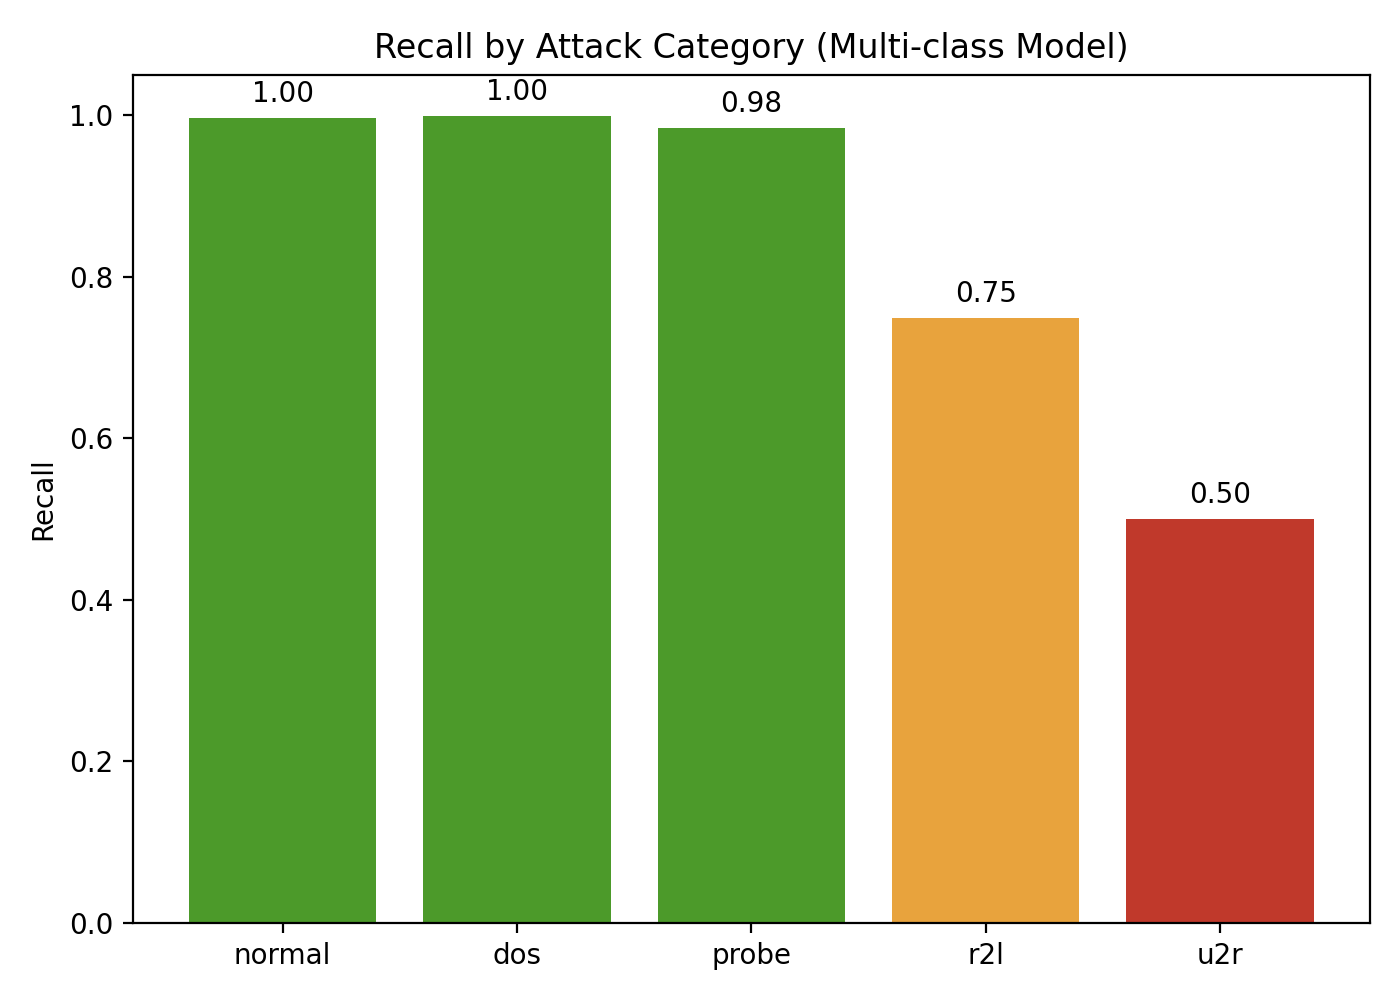

In [140]:
make_download_link('/kaggle/working/recall_by_category.png', 'recall_by_category.png')

## 10. Sequential Agent Layer: Adding Decision Memory

The classifier above scores each connection independently (episodic). This section adds a rule that uses the dataset's existing windowed host-history features to escalate borderline decisions based on recent context, and runs the agent as a streaming loop over connections in arrival order.

In [141]:
# --- Turning the episodic classifier into a simple sequential agent ---
#
# Per-row, the classifier is episodic: it scores each connection in
# isolation. But NSL-KDD's own dst_host_* features are already computed
# over a 2-second window of PRECEDING connections to the same host, so
# real sequential context exists in the data, it's just not being used
# as decision memory. This pass adds an explicit agent rule that uses
# that existing windowed context to escalate borderline decisions,
# which is what makes the agent's behavior sequential, not the model.
#
# It also runs as a streaming loop, processing connections one at a time
# in arrival order, rather than batch-predicting the whole test set at
# once. That loop is the actual shape a live sensor feed would take.

def sequential_agent_stream(X_test_df, y_pred, confidence, threshold=0.90,
                             host_activity_col='dst_host_count',
                             error_rate_col='dst_host_serror_rate',
                             activity_threshold=50, error_threshold=0.5,
                             verbose_first_n=10):
    decisions = []
    escalated = 0

    for i in range(len(X_test_df)):
        # --- simulates one connection arriving from a live sensor ---
        row = X_test_df.iloc[i]
        p, conf = y_pred[i], confidence[i]

        if conf < threshold:
            d = 'flag'
        elif p == 'attack':
            d = 'block'
        else:
            d = 'allow'

        # Sequential escalation: this host has heavy recent traffic AND a
        # high recent SYN-error rate (both windowed, history-based signals
        # already present in the row). Don't let a low-confidence 'allow'
        # through just because this one row looked fine in isolation.
        if d == 'allow' and row[host_activity_col] >= activity_threshold and row[error_rate_col] >= error_threshold:
            d = 'flag'
            escalated += 1

        if i < verbose_first_n:
            print(f"conn {i:>5} | base_pred={p:<7} conf={conf:.2f} | "
                  f"host_activity={row[host_activity_col]:<4} host_err={row[error_rate_col]:.2f} -> decision={d}")

        decisions.append(d)

    print(f"\n{escalated} connections were escalated from 'allow' to 'flag' "
          f"by sequential host-history context alone.")
    return pd.Series(decisions)


seq_decisions = sequential_agent_stream(X_test, y_pred, confidence)
print()
print(seq_decisions.value_counts())
print((seq_decisions.value_counts(normalize=True) * 100).round(2))

conn     0 | base_pred=attack  conf=1.00 | host_activity=255.0 host_err=0.00 -> decision=block
conn     1 | base_pred=attack  conf=1.00 | host_activity=255.0 host_err=0.00 -> decision=block
conn     2 | base_pred=normal  conf=1.00 | host_activity=134.0 host_err=0.00 -> decision=allow
conn     3 | base_pred=attack  conf=1.00 | host_activity=3.0  host_err=0.00 -> decision=block
conn     4 | base_pred=normal  conf=1.00 | host_activity=29.0 host_err=0.00 -> decision=allow
conn     5 | base_pred=normal  conf=1.00 | host_activity=155.0 host_err=0.01 -> decision=allow
conn     6 | base_pred=normal  conf=0.98 | host_activity=255.0 host_err=0.00 -> decision=allow
conn     7 | base_pred=normal  conf=1.00 | host_activity=255.0 host_err=0.01 -> decision=allow
conn     8 | base_pred=normal  conf=1.00 | host_activity=151.0 host_err=0.00 -> decision=allow
conn     9 | base_pred=normal  conf=1.00 | host_activity=52.0 host_err=0.00 -> decision=allow

307 connections were escalated from 'allow' to 'flag

In [142]:
# Compare: how many cases changed because the agent now has sequential
# memory, versus the original purely episodic, no-memory version?
comparison = pd.DataFrame({'episodic': decisions.values, 'sequential': seq_decisions.values})
changed = comparison[comparison['episodic'] != comparison['sequential']]
print(f"{len(changed)} connections got a different decision once sequential host-history was added:")
print(changed['episodic'].value_counts(), '\n->\n', changed['sequential'].value_counts())

307 connections got a different decision once sequential host-history was added:
episodic
allow    307
Name: count, dtype: int64 
->
 sequential
flag    307
Name: count, dtype: int64


In [143]:
escalated_mask = (comparison['episodic'] == 'allow') & (comparison['sequential'] == 'flag')
print('What were the 307 escalated connections actually?')
print(y_test[escalated_mask.values].value_counts())

What were the 307 escalated connections actually?
binary_label
attack    282
normal     25
Name: count, dtype: int64


## 11. Agent Limitations in Production

Translating the model's measured performance into what it means for an agent deployed on a live network feed.

**Accuracy and recall**
The binary baseline catches 62% of attacks (recall) at 96% precision when blocking. That means roughly 38% of real attacks would pass through as "allow" or get caught only later by the sequential escalation rule. The multi-class model is far worse on rare categories: u2r recall is near zero in the harder evaluation, meaning this attack type would almost never be flagged. An agent built on this model needs a fallback layer (signature rules, human review queue) for exactly the attack types the model is weakest on, not just an overall accuracy number.

**Kinds of errors**
False negatives (attack labeled "allow") are the costly error here; a missed attack reaches its target. False positives (normal labeled "block") cost user trust and support tickets but not security. The confidence-threshold policy turns this asymmetry into a rule: low-confidence cases get routed to "flag" for human review instead of an automatic decision either way.

**Speed**
A decision tree of depth 8 makes its prediction in a handful of comparisons, fast enough for per-connection real-time decisions on a live feed. This matters for an agent that has to act inline on network traffic, not in a batch job.

**Resource needs**
Training and inference here both run on a standard CPU with no GPU requirement. This keeps the agent cheap to deploy and retrain, which matters because the model needs reasonably frequent retraining as new attack patterns emerge, given how poorly it generalizes to unseen attack subtypes.

**What this means for the agent's design**
The model alone is not safe to deploy as a fully autonomous blocker. Its value to the agent is as one signal feeding a decision policy that also weighs confidence and recent host history, with a human-in-the-loop path for the cases it is least sure about.